# Skin Lesion Classification with Deep Learning

## Project Overview

Skin cancer is among the most common cancers worldwide, and early detection through dermoscopic image analysis is critical for improving patient outcomes. Automated classification of skin lesions from dermoscopy images can assist dermatologists in prioritizing cases and reducing diagnostic error.

In this project, a **Convolutional Neural Network (CNN)** is built to classify dermoscopy images into **7 distinct skin lesion categories** using the **DermaMNIST** dataset, derived from the widely cited HAM10000 clinical benchmark.

### Dataset
**DermaMNIST** is derived from the HAM10000 dataset, a large collection of multi-source dermatoscopic images of common pigmented skin lesions. It contains **10,015 images** resized to 28x28 pixels across 7 classes: actinic keratoses, basal cell carcinoma, benign keratosis, dermatofibroma, melanoma, melanocytic nevi, and vascular lesions.

### Objectives
- Load and inspect the DermaMNIST dataset across all 7 classes
- Preprocess images and handle class imbalance with class weighting
- Build and train a CNN for multi-class classification
- Evaluate performance using Accuracy, AUC-ROC, and a Confusion Matrix

### Tools and Libraries
`Python` · `NumPy` · `Matplotlib` · `Seaborn` · `Scikit-learn` · `TensorFlow / Keras` · `MedMNIST`

In [12]:
# Imports and Setup
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import medmnist
from medmnist import DermaMNIST, INFO

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print("TensorFlow version:", tf.__version__)
print("MedMNIST version  :", medmnist.__version__)
print("All libraries loaded successfully")

TensorFlow version: 2.20.0
MedMNIST version  : 3.0.2
All libraries loaded successfully


## Loading and Inspecting the Dataset

The DermaMNIST dataset is loaded directly through the MedMNIST API across the three predefined splits. We inspect the class names, image shapes, and the distribution of samples across all 7 lesion categories to understand the scale and balance of the data before any preprocessing.

In [13]:
# Load dataset info
info = INFO["dermamnist"]
print("Classes:")
for k, v in info["label"].items():
    print(f"  {k}: {v}")
print("n_channels:", info["n_channels"])

# Download and load splits
train_data = DermaMNIST(split="train", download=True)
val_data   = DermaMNIST(split="val",   download=True)
test_data  = DermaMNIST(split="test",  download=True)

# Extract arrays
X_train = np.array([np.array(s[0]) for s in train_data])
y_train = np.array([s[1][0] for s in train_data])

X_val   = np.array([np.array(s[0]) for s in val_data])
y_val   = np.array([s[1][0] for s in val_data])

X_test  = np.array([np.array(s[0]) for s in test_data])
y_test  = np.array([s[1][0] for s in test_data])

print("\nSplit sizes:")
print(f"  Train : {X_train.shape}, labels: {y_train.shape}")
print(f"  Val   : {X_val.shape},   labels: {y_val.shape}")
print(f"  Test  : {X_test.shape},  labels: {y_test.shape}")

print("\nClass distribution (Train):")
class_names = list(info["label"].values())
for i, name in enumerate(class_names):
    count = np.sum(y_train == i)
    print(f"  {name}: {count}")

Classes:
  0: actinic keratoses and intraepithelial carcinoma
  1: basal cell carcinoma
  2: benign keratosis-like lesions
  3: dermatofibroma
  4: melanoma
  5: melanocytic nevi
  6: vascular lesions
n_channels: 3


100%|██████████| 19.7M/19.7M [00:03<00:00, 6.01MB/s]



Split sizes:
  Train : (7007, 28, 28, 3), labels: (7007,)
  Val   : (1003, 28, 28, 3),   labels: (1003,)
  Test  : (2005, 28, 28, 3),  labels: (2005,)

Class distribution (Train):
  actinic keratoses and intraepithelial carcinoma: 228
  basal cell carcinoma: 359
  benign keratosis-like lesions: 769
  dermatofibroma: 80
  melanoma: 779
  melanocytic nevi: 4693
  vascular lesions: 99


### Observations

The dataset loaded cleanly with **7,007 training images**, 1,003 validation images, and 2,005 test images. DermaMNIST images here are RGB with 3 channels, which is appropriate for dermoscopy images where color is a diagnostically meaningful feature — lesion pigmentation patterns are a key visual cue used by dermatologists.

The class imbalance here is considerably more severe than in Project 2. Melanocytic nevi dominates the training set with **4,693 samples**, representing 67% of all training images, while dermatofibroma and vascular lesions have only 80 and 99 samples respectively. This extreme imbalance means class weighting will be critical — without it, the model would likely collapse into predicting melanocytic nevi for nearly every input and still achieve superficially high accuracy.

## Visualizing Sample Images

A sample image from each of the 7 lesion classes is displayed to get a visual sense of the data. Even at 28x28 resolution, color and texture differences across the lesion types are apparent, which are the key visual features the CNN will need to learn to distinguish between classes.

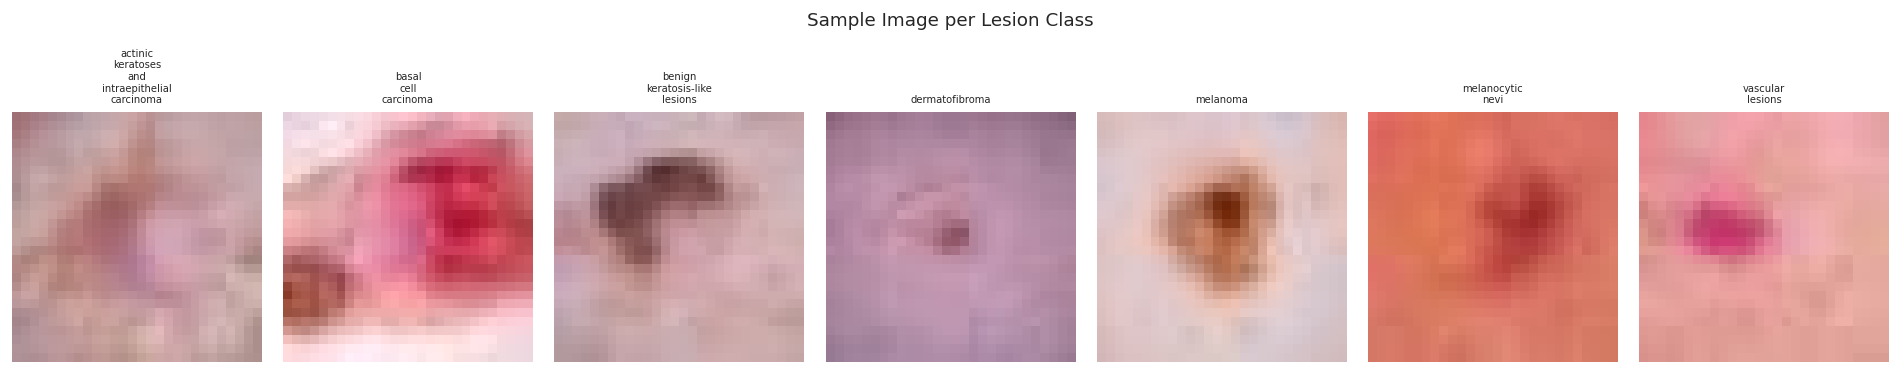

In [14]:
fig, axes = plt.subplots(1, 7, figsize=(16, 3))

for i, name in enumerate(class_names):
    idx = np.where(y_train == i)[0][0]
    axes[i].imshow(X_train[idx])
    axes[i].axis("off")
    axes[i].set_title(name.replace(" ", "\n"), fontsize=6)

plt.suptitle("Sample Image per Lesion Class", fontsize=11, y=1.05)
plt.tight_layout()
plt.savefig("sample_images.png", bbox_inches="tight")
plt.show()

### Observations

The sample images reveal meaningful visual diversity across the 7 classes despite the low resolution. Several distinguishing characteristics are visible:

- **Actinic keratoses** and **basal cell carcinoma** show irregular reddish, inflamed tissue with uneven pigmentation
- **Benign keratosis-like lesions** display a darker, more defined central mass against lighter surrounding skin
- **Dermatofibroma** appears notably lighter and more uniform, with a subtle central structure
- **Melanoma** shows a concentrated dark brown pigmented core with irregular borders
- **Melanocytic nevi** presents as a reddish-toned lesion blending into surrounding skin
- **Vascular lesions** are visually distinct with a bright pink to magenta coloration, making them arguably the most visually separable class

The color channel information is clearly meaningful here — several classes would be considerably harder to distinguish in grayscale, which justifies the RGB representation of this dataset.

## Preprocessing and Preparing the Data

Pixel values are normalized from their original 0–255 range to 0–1. The images are already in the correct shape of `(28, 28, 3)` so no channel dimension expansion is needed.

Given the severe class imbalance — particularly the dominance of melanocytic nevi and the very small counts for dermatofibroma and vascular lesions — class weights are computed to ensure the model is penalized appropriately for misclassifying underrepresented classes. A data augmentation pipeline applying random horizontal and vertical flips along with small rotations is used to improve generalization, particularly for the minority classes which have very few training examples to learn from.

In [15]:
# Normalize pixel values to [0, 1]
X_train_n = X_train.astype("float32") / 255.0
X_val_n   = X_val.astype("float32")   / 255.0
X_test_n  = X_test.astype("float32")  / 255.0

print("Shape after preprocessing:")
print(f"  Train : {X_train_n.shape}")
print(f"  Val   : {X_val_n.shape}")
print(f"  Test  : {X_test_n.shape}")

# Compute class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("\nClass weights:")
for i, name in enumerate(class_names):
    print(f"  {name}: {class_weight_dict[i]:.4f}")

# Data augmentation pipeline
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.1),
], name="data_augmentation")

print("\nPreprocessing complete")

Shape after preprocessing:
  Train : (7007, 28, 28, 3)
  Val   : (1003, 28, 28, 3)
  Test  : (2005, 28, 28, 3)

Class weights:
  actinic keratoses and intraepithelial carcinoma: 4.3904
  basal cell carcinoma: 2.7883
  benign keratosis-like lesions: 1.3017
  dermatofibroma: 12.5125
  melanoma: 1.2850
  melanocytic nevi: 0.2133
  vascular lesions: 10.1111

Preprocessing complete


### Results

Normalization completed successfully with all splits retaining their original shapes. The class weights computed reflect the imbalance precisely. Melanocytic nevi, which dominates the training set, receives the lowest weight of **0.21**, meaning its correct predictions contribute the least to the loss. At the other extreme, dermatofibroma and vascular lesions receive weights of **12.51** and **10.11** respectively, making misclassifications of these rare classes heavily penalized during training.

This weighting spread is considerably wide, reflecting the severity of the class imbalance. Without these weights, the model would have little incentive to learn the distinguishing features of the four minority classes.

## Building the Model

The model follows the same general CNN architecture of stacked convolutional blocks, but is adapted for the multi-class nature of this problem. Four convolutional blocks are used here rather than three, giving the network more capacity to learn the finer distinctions between 7 visually similar lesion classes. Each block consists of a Conv2D layer with ReLU activation, batch normalization, and max pooling.

The classifier head uses two dense layers with dropout before the final output layer, which has **7 neurons with softmax activation** — appropriate for mutually exclusive multi-class classification. The model is compiled with sparse categorical cross-entropy loss since the labels are integer-encoded rather than one-hot encoded.

In [16]:
def build_cnn(input_shape=(28, 28, 3), num_classes=7):
    model = keras.Sequential([
        # Augmentation
        data_augmentation,

        # Block 1
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Block 2
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Block 3
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Block 4
        layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),

        # Classifier head
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = build_cnn()
model.build(input_shape=(None, 28, 28, 3))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 28, 28, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 3, 3, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 3, 3, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,014,215 (3.87 MB)

 Trainable params: 1,013,255 (3.87 MB)

 Non-trainable params: 960 (3.75 KB)

### Model Summary

The network has **1,014,215 total parameters**, of which 1,013,255 are trainable. The larger parameter count compared to a binary classification CNN is justified by the increased complexity of distinguishing 7 visually similar lesion classes from small 28x28 RGB images.

The four convolutional blocks progressively reduce spatial dimensions from 28x28 down to 3x3 while growing the feature map depth from 32 to 256, allowing the network to build increasingly abstract representations of lesion texture and color patterns. The fourth convolutional block does not include max pooling since the spatial dimensions are already reduced to 3x3 at that point — further pooling would discard too much spatial information before the classifier head.

The dense layers compress the 2,304-dimensional flattened feature vector down to the final 7-class softmax output, with dropout rates of 0.5 and 0.3 applied to limit overfitting given the class imbalance and limited minority class samples.

## Training the Model

The model is trained for up to 100 epochs with a batch size of 32. Early stopping monitors validation loss with a patience of 15 epochs, and the learning rate scheduler halves the rate when validation loss does not improve for 7 consecutive epochs. Class weights are passed to the training loop to counter the heavy imbalance across the 7 lesion categories.

In [17]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=7,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train_n, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val_n, y_val),
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)

print("Training complete")
print("Total epochs run:", len(history.history["loss"]))

Epoch 1/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 32s 125ms/step - accuracy: 0.3348 - loss: 2.2720 - val_accuracy: 0.1097 - val_loss: 2.0738 - learning_rate: 0.0010
Epoch 2/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 43s 132ms/step - accuracy: 0.3702 - loss: 1.7692 - val_accuracy: 0.1266 - val_loss: 2.1312 - learning_rate: 0.0010
Epoch 3/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 27s 122ms/step - accuracy: 0.3491 - loss: 1.7365 - val_accuracy: 0.3848 - val_loss: 1.5182 - learning_rate: 0.0010
Epoch 4/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 41s 120ms/step - accuracy: 0.3771 - loss: 1.6562 - val_accuracy: 0.3370 - val_loss: 1.5224 - learning_rate: 0.0010
Epoch 5/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 42s 123ms/step - accuracy: 0.3641 - loss: 1.6620 - val_accuracy: 0.0758 - val_loss: 2.5916 - learning_rate: 0.0010
Epoch 6/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 26s 121ms/step - accuracy: 0.3823 - loss: 1.5854 - val_accuracy: 0.2921 - val_loss: 1.6867 - learning_rate: 0.0010
Epoch 7/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 41s 121ms/step - accura

### Training Results

Training ran for 37 epochs before early stopping halted it, with the best weights restored from **epoch 35** where validation loss reached its lowest point at 0.9655 and validation accuracy stood at 53.24%.

The early epochs were notably unstable, with validation loss spiking as high as 2.59 at epoch 5 before settling into a more consistent downward trend from epoch 7 onward. This instability is expected given the extreme class imbalance and the high class weights assigned to the minority classes, which create large loss gradients in the early training stages.

The learning rate was reduced three times — at epochs 14, 29, and 36 — with each reduction helping the model make more careful weight updates. The most meaningful improvement came between epochs 20 and 35, where validation loss dropped steadily from 1.08 to 0.97 as training accuracy climbed from 49% to 55%.

The relatively modest accuracy figures are consistent with the inherent difficulty of this task — distinguishing 7 visually similar lesion classes from 28x28 images with severe class imbalance is a genuinely challenging problem, and the class weighting strategy prioritizes correct identification of rare but clinically significant lesion types over raw accuracy.

## Visualizing Training History

The loss and accuracy curves are plotted across all training epochs. The dashed vertical line marks the best epoch from which weights were restored by early stopping.

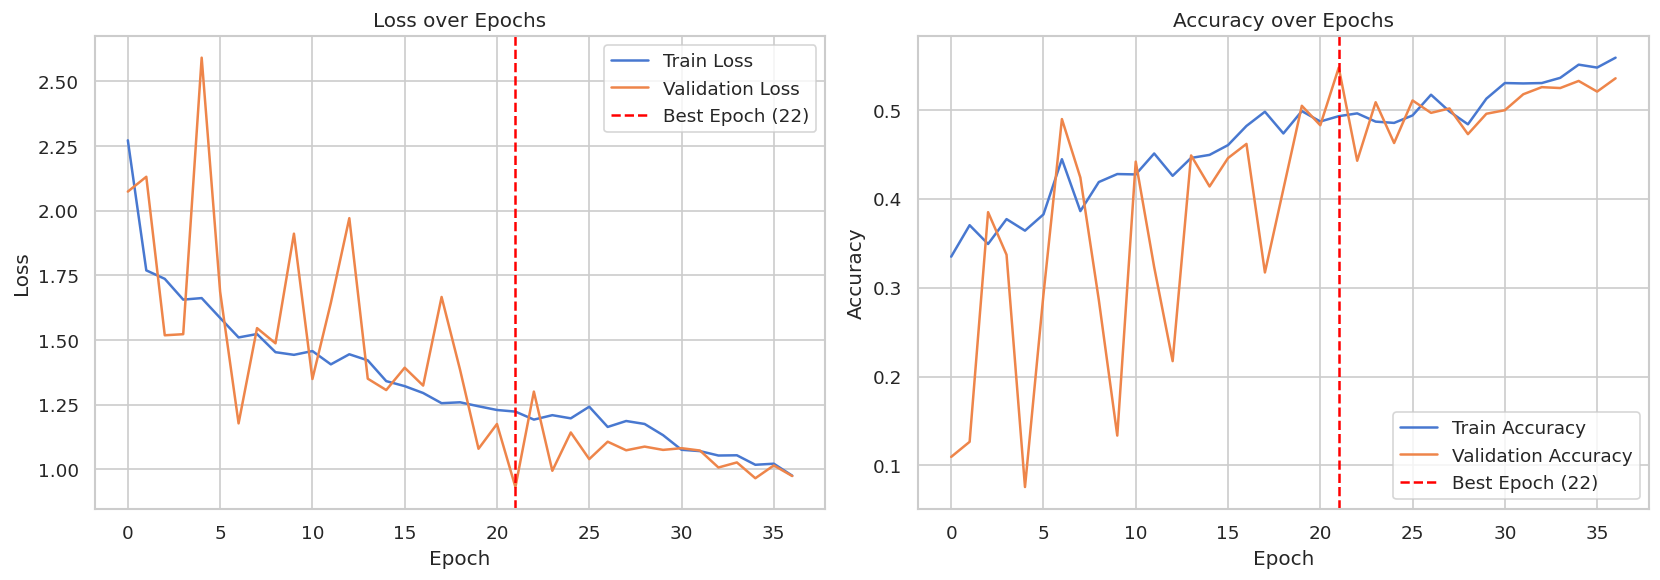

In [18]:
best_epoch = np.argmin(history.history["val_loss"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Validation Loss")
axes[0].axvline(best_epoch, color="red", linestyle="--",
                label=f"Best Epoch ({best_epoch + 1})")
axes[0].set_title("Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Accuracy curves
axes[1].plot(history.history["accuracy"], label="Train Accuracy")
axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
axes[1].axvline(best_epoch, color="red", linestyle="--",
                label=f"Best Epoch ({best_epoch + 1})")
axes[1].set_title("Accuracy over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig("training_history.png", bbox_inches="tight")
plt.show()

### Analysis

The plots reveal that the best epoch was actually **epoch 22**, where validation loss reached 0.9315 — the true minimum across all training epochs. Both curves follow a broadly consistent downward trend from epoch 7 onward, with the two losses tracking each other reasonably closely throughout, which indicates the model was learning genuine patterns rather than overfitting.

The validation curves are visibly noisier than the training curves, with several sharp dips and spikes particularly in the first 15 epochs. This volatility is a direct consequence of the heavy class weights assigned to the minority classes — a small number of misclassified dermatofibroma or vascular lesion samples in any given validation batch produces a disproportionately large loss spike.

From epoch 20 onward both curves stabilize and converge, with training and validation accuracy tracking closely in the 45–55% range. The absence of a large gap between the two accuracy curves is a positive sign — it suggests the dropout regularization and class weighting together prevented the model from collapsing into predicting only the dominant class.

## Model Evaluation on the Test Set

The model is evaluated on the 2,005-sample held-out test set. For a 7-class problem, the confusion matrix becomes particularly informative — it shows not just how many samples were misclassified but which classes are being confused with each other, which carries direct clinical relevance. The AUC-ROC score is computed using a one-vs-rest strategy to handle the multi-class setting.

Test Loss    : 0.9519
Test Accuracy: 0.5526

Classification Report:
              precision    recall  f1-score   support

  Actinic K.       0.16      0.30      0.21        66
  Basal Cell       0.33      0.08      0.13       103
   Benign K.       0.47      0.45      0.46       220
 Dermatofib.       0.07      0.35      0.12        23
    Melanoma       0.25      0.69      0.37       223
   Mel. Nevi       0.95      0.59      0.73      1341
    Vascular       0.32      0.86      0.47        29

    accuracy                           0.55      2005
   macro avg       0.37      0.48      0.35      2005
weighted avg       0.74      0.55      0.60      2005

AUC-ROC Score (macro OvR): 0.8835


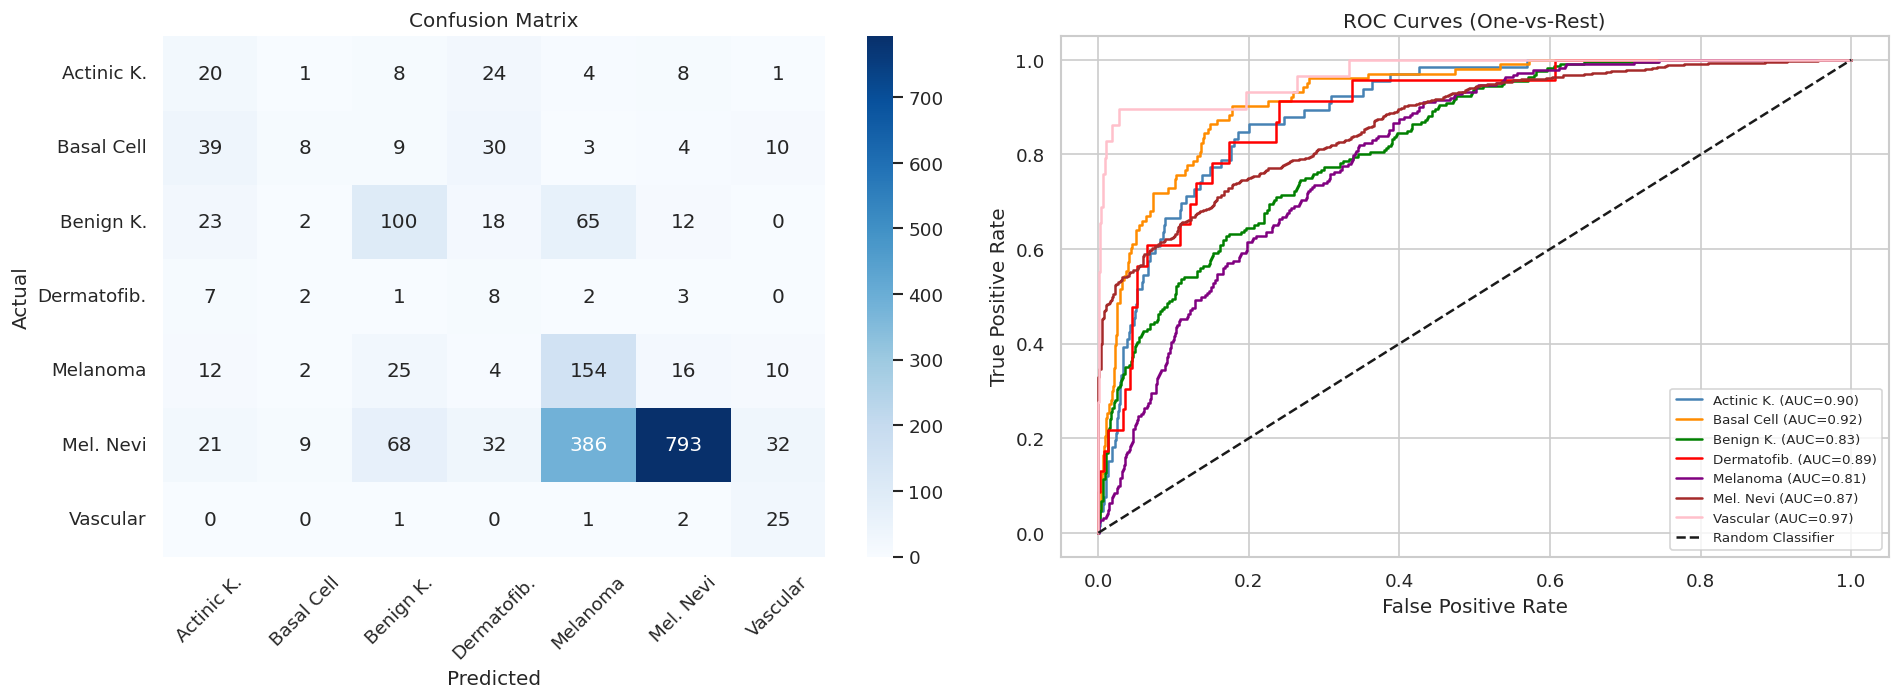

In [19]:
# Loss and accuracy on test set
test_loss, test_accuracy = model.evaluate(X_test_n, y_test, verbose=0)
print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Predictions
y_pred_prob = model.predict(X_test_n, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)

# Classification report
print("\nClassification Report:")
short_names = ["Actinic K.", "Basal Cell", "Benign K.",
               "Dermatofib.", "Melanoma", "Mel. Nevi", "Vascular"]
print(classification_report(y_test, y_pred, target_names=short_names))

# AUC-ROC score (one-vs-rest)
y_test_bin = label_binarize(y_test, classes=list(range(7)))
auc = roc_auc_score(y_test_bin, y_pred_prob,
                    multi_class="ovr", average="macro")
print(f"AUC-ROC Score (macro OvR): {auc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=short_names, yticklabels=short_names)
axes[0].set_title("Confusion Matrix")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")
axes[0].tick_params(axis="x", rotation=45)

# ROC curve per class
colors = ["steelblue", "darkorange", "green", "red",
          "purple", "brown", "pink"]
for i, (name, color) in enumerate(zip(short_names, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    auc_i = roc_auc_score(y_test_bin[:, i], y_pred_prob[:, i])
    axes[1].plot(fpr, tpr, color=color, label=f"{name} (AUC={auc_i:.2f})")

axes[1].plot([0, 1], [0, 1], "k--", label="Random Classifier")
axes[1].set_title("ROC Curves (One-vs-Rest)")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("evaluation.png", bbox_inches="tight")
plt.show()

### Results

The model achieved a **test accuracy of 55.26%** and a **macro AUC-ROC score of 0.8835** across all 7 classes. The gap between these two metrics tells an important story — while raw accuracy appears modest, the high AUC score indicates the model has genuinely learned to rank and separate the classes, and that much of the difficulty lies in setting the right decision boundary rather than a failure to learn discriminative features.

**Confusion Matrix:** Melanocytic nevi, the dominant class, is the most reliably classified with 793 correct predictions, though it also absorbs a large number of misclassifications from other classes — particularly melanoma (16 cases misclassified as mel. nevi) and benign keratosis (68 cases). This is clinically concerning since melanoma being misclassified as a benign nevus is exactly the type of error that carries the highest patient risk. Vascular lesions perform surprisingly well given their small support, with 25 out of 29 correctly identified, likely because their distinctive coloration makes them visually separable even at low resolution. Basal cell carcinoma and actinic keratoses are the weakest performers, with F1-scores of 0.13 and 0.21 respectively, reflecting both their limited training samples and their visual similarity to other lesion types.

**ROC Curves:** The per-class AUC scores range from 0.81 for melanoma to 0.97 for vascular lesions. All seven classes sit well above the random classifier diagonal, confirming the model has learned meaningful discriminative features for every class. The relatively lower AUC for melanoma at 0.81 is noteworthy — it is the most clinically critical class to get right, and its visual overlap with melanocytic nevi makes it the hardest distinction for the model to make reliably at this resolution.

**Overall:** The results are consistent with what is achievable on a severely imbalanced 7-class medical imaging task at 28x28 resolution. The macro AUC of 0.88 demonstrates the model has real discriminative value across all lesion types, and the class weighting strategy ensured that even the rarest classes — dermatofibroma and vascular lesions — were not ignored by the model during training.